Shewhart kan bruges som baseline, fordi den beskriver univariat statistical monitoring som limit sensing med upper/lower control limites. 

Men ulempen er også at limit sensing ignorerer interaktioner mellem procesvariable. 

Så Shewhart skal præsenteres som: 
- simpel baseline-metode, let at forstå, men svarere end PCA/FDA fordi den ikke modellerer multivariable sensorrelationer. 


## Data import 

Vi finder projektmappen, tilføjer den til sys.path, importerer biblioteker og loader FaultyCase1.mat

Loader Set1_1, Set1_2 og Set1_3 som TimeSeriesDataset-objekter og fault_info gemmer fault-start og fault-end for hvert datasæt

In [16]:
import sys
from pathlib import Path

cwd = Path.cwd()

while not ((cwd / "data").exists() or (cwd / "CVACaseStudy").exists()):
    if cwd.parent == cwd:
        raise RuntimeError("Kunne ikke finde projekt root")
    cwd = cwd.parent

PROJECT_ROOT = cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

from fdd.dataloader import DataLoader
from fdd.preprocessor import StandardPreprocessor
from fdd.dataset import TimeSeriesDataset

def find_file(root, filename):
    matches = list(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"{filename} not found under {root}")
    return sorted(matches, key=lambda p: len(str(p)))[0]

DATA_PATH = find_file(PROJECT_ROOT, "FaultyCase1.mat")

loader = DataLoader(DATA_PATH)
datasets = loader.load()

fault_info = {
    "Set1_1": {"start": 1566, "end": 5181, "description": "Changing conditions"},
    "Set1_2": {"start": 657, "end": 3777, "description": "Steady-state 1"},
    "Set1_3": {"start": 691, "end": 3691, "description": "Steady-state 2"},
}

for name, ds in datasets.items():
    print(name, ds.summary())

Set1_1 TimeSeriesDataset(name=Set1_1, n_samples=5811, n_features=23)
Set1_2 TimeSeriesDataset(name=Set1_2, n_samples=4467, n_features=23)
Set1_3 TimeSeriesDataset(name=Set1_3, n_samples=4321, n_features=23)


## Evalueringsfunktioner

Definerer målene til evaluering, laver en sand/falsk label serie, hvor 0 = normal og 1 = fault.

Beregner 
- Første alarm efter fault-start
- Detection delay
- Antal alarmer før, under og efter fault
- False alarm rate
- Fault detection rate 

Mest relevant for FDA, ikke så vigtig for Shewhart

In [17]:
def make_ground_truth(n_samples, fault_start, fault_end):
    y = np.zeros(n_samples, dtype=int)
    y[fault_start:fault_end + 1] = 1
    return y


def evaluate_alarm(alarm, fault_start, fault_end):
    alarm = np.asarray(alarm).astype(bool)

    before_fault = alarm[:fault_start]
    during_fault = alarm[fault_start:fault_end + 1]
    after_fault = alarm[fault_end + 1:]

    alarm_indices_after_start = np.where(alarm[fault_start:])[0]

    if len(alarm_indices_after_start) == 0:
        first_alarm_after_fault = None
        detection_delay = None
    else:
        first_alarm_after_fault = int(alarm_indices_after_start[0] + fault_start)
        detection_delay = int(first_alarm_after_fault - fault_start)

    return {
        "first_alarm_after_fault": first_alarm_after_fault,
        "detection_delay": detection_delay,
        "n_alarms_total": int(alarm.sum()),
        "n_alarms_before_fault": int(before_fault.sum()),
        "n_alarms_during_fault": int(during_fault.sum()),
        "n_alarms_after_fault": int(after_fault.sum()),
        "false_alarm_rate_before_fault": float(before_fault.mean()) if len(before_fault) else np.nan,
        "fault_detection_rate": float(during_fault.mean()) if len(during_fault) else np.nan,
    }


def evaluate_classifier(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_fault": precision_score(y_true, y_pred, zero_division=0),
        "recall_fault": recall_score(y_true, y_pred, zero_division=0),
        "f1_fault": f1_score(y_true, y_pred, zero_division=0),
    }

## Visualisering

Visualisering af datasættet, denne blok primter summary for hvert datasæt og viser de første rækker. Formålet er bare at kontrollere, at data er loaded korrekt

In [18]:
for name, dataset in datasets.items():
    print(dataset.summary())
    display(dataset.sensors.head())

TimeSeriesDataset(name=Set1_1, n_samples=5811, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,0.123671,0.118994,0.099840,0.102702,0.099423,0.019198,0.248773,0.020653,0.493771,-0.246817,...,995.862488,996.525513,20.018761,20.923019,21.754801,7.324118,21.015640,46.294441,28.072460,2.1050
1,0.123146,0.118504,0.099780,0.102566,0.099522,0.018732,0.288827,0.020645,0.493793,-0.246817,...,995.862610,996.518677,20.015230,20.922810,21.761770,7.321606,21.023270,46.311249,28.073271,2.0150
2,0.122749,0.118401,0.099980,0.102515,0.099621,0.018358,0.270946,0.020638,0.493816,-0.246818,...,995.862793,996.511780,20.011700,20.922609,21.768749,7.319094,21.035440,46.328072,28.074089,1.9175
3,0.122648,0.118266,0.100266,0.102741,0.099721,0.018015,0.240905,0.020636,0.493838,-0.246819,...,995.862976,996.505005,20.008169,20.922409,21.775721,7.316582,21.047621,46.344879,28.074909,1.9150
4,0.122463,0.117908,0.100248,0.103059,0.099792,0.017672,0.271661,0.020635,0.493860,-0.246819,...,995.863098,996.498230,20.004641,20.922199,21.782700,7.314071,21.059790,46.361698,28.075729,2.1375


TimeSeriesDataset(name=Set1_2, n_samples=4467, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,0.134422,0.128272,0.102251,0.104552,0.099477,0.026017,0.395401,0.041172,1.988174,0.345307,...,987.024170,997.685425,20.788589,19.79677,19.106760,35.205521,27.12253,88.334503,43.250599,2.2100
1,0.134377,0.128434,0.102302,0.104471,0.099487,0.026034,0.470502,0.041136,1.989220,0.128820,...,987.656128,997.685486,20.789459,19.79862,18.965611,35.207569,27.11714,88.385307,43.258072,2.2900
2,0.134632,0.128661,0.102409,0.104656,0.099497,0.026203,0.429733,0.041123,1.992013,0.014496,...,988.288086,997.685486,20.790331,19.80048,18.918560,35.209610,27.11174,88.436111,43.265541,2.1000
3,0.134634,0.128690,0.102516,0.104800,0.099507,0.026164,0.316007,0.041084,1.994807,0.458081,...,988.919983,997.685486,20.791210,19.80234,18.918560,35.211651,27.10635,88.486923,43.273010,1.9975
4,0.134763,0.128653,0.102623,0.104902,0.099517,0.026040,0.292404,0.041065,1.997600,0.412542,...,989.552002,997.685608,20.792080,19.80419,18.918560,35.213699,27.10095,88.537727,43.280479,2.1775


TimeSeriesDataset(name=Set1_3, n_samples=4321, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,0.148614,0.144112,0.099908,0.102331,0.099692,0.044019,0.657899,0.021139,3.493562,-0.119259,...,278.099609,998.15802,21.240061,21.056549,20.549940,34.029011,20.176050,47.243179,56.314251,2.4075
1,0.148712,0.144223,0.099980,0.102346,0.099749,0.044139,0.664337,0.021129,3.493410,-0.204256,...,274.954712,998.15802,21.240170,21.055470,20.549940,34.016430,20.188910,47.229820,56.316959,2.4150
2,0.148811,0.144334,0.100075,0.102346,0.099805,0.044162,0.675781,0.021120,3.493258,-0.246815,...,278.543915,998.15802,21.240280,21.054399,20.549940,34.003399,20.201780,47.216461,56.319679,2.3925
3,0.148909,0.144444,0.100153,0.102410,0.099861,0.044153,0.700099,0.021112,3.493105,-0.122358,...,280.331696,998.15802,21.240391,21.053320,20.597019,33.990379,20.214649,47.203110,56.322392,2.4950
4,0.149008,0.144440,0.100224,0.102479,0.099917,0.044143,0.709398,0.021104,3.492953,-0.041533,...,285.598602,998.15802,21.240490,21.052250,20.612711,33.977360,20.227510,47.189751,56.325100,2.5000


## Plot en sensor

Denne blok plotter "P_Bottom_Riser" for alle tre datasæt or markerer fault-start og fault-end. Den bruges til visuel forståelse, hvor vi kan se om sensoren ændrer sig omkring fault-perioden

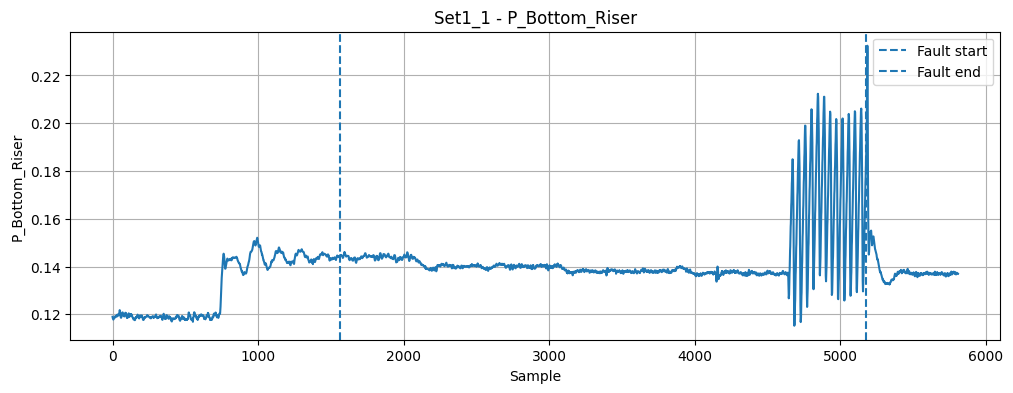

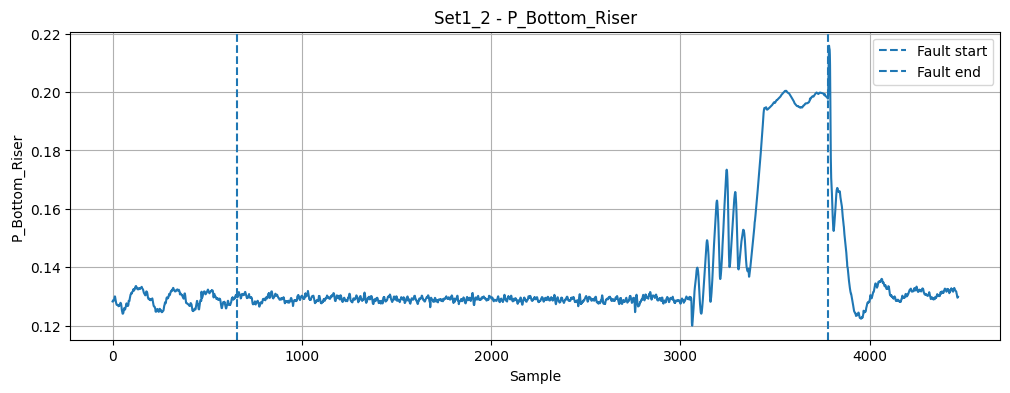

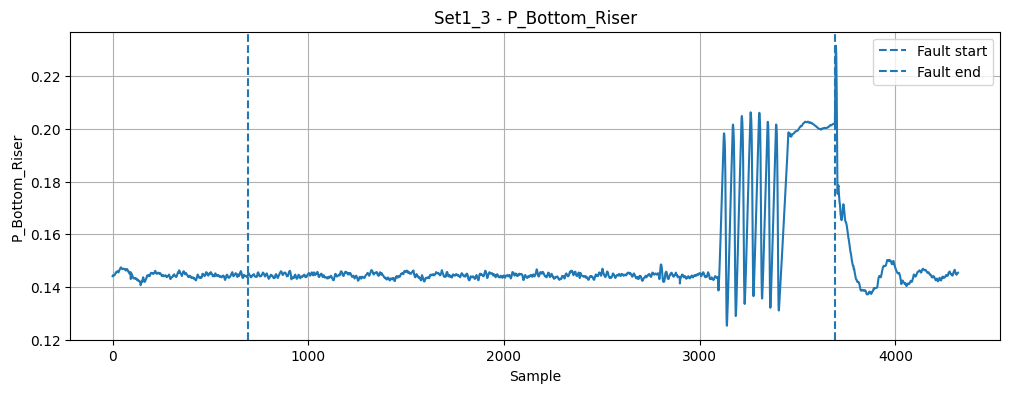

In [11]:
sensor = "P_Bottom_Riser"

for name, dataset in datasets.items():
    plt.figure(figsize=(12, 4))
    plt.plot(dataset.sensors[sensor])
    plt.axvline(fault_info[name]["start"], linestyle="--", label="Fault start")
    plt.axvline(fault_info[name]["end"], linestyle="--", label="Fault end")
    plt.title(f"{name} - {sensor}")
    plt.xlabel("Sample")
    plt.ylabel(sensor)
    plt.grid(True)
    plt.legend()
    plt.show()

## Vælg Shewhart sensorer

Her vælger vi de sensorer, som Shewhart modellen skal bruge. 
- Vote_threshold = 2 betyder, at den samlede model først giver alarm, når mindst 2 sensorer er i alarm samtidig 
- k_sigma = 3 betyder, at hver sensor bruger +/- 3 standardafivgelser som kontrolgrænse 

Shewhart virker bedst på udvalgte sensorer, hvor fault visuelt kan ses

In [19]:
shewhart_sensors = [
    "Air_Delivery_P",
    "P_Bottom_Riser",
    "Diff_P_VC404",
    "Air_In_Flow",
    "Flow_Top_Riser",
]

vote_threshold = 2
k_sigma = 3

## Fit Shewhart modeller

Denne blok træner Shewhart grænserne 

For hver sensor: 
- Den tager kun data før faulty-start 
- Samler healthy-data fra alle tre datasæt 
- Beregner middelværdi og standardafvigelse 
- Laver grænser

Tabellen viser CL, sigma, LCL, UCL og alle træningspunkter

In [20]:
def fit_shewhart_models(datasets, fault_info, sensors, k=3):
    models = {}

    for sensor in sensors:
        train_parts = []

        for name, dataset in datasets.items():
            fault_start = fault_info[name]["start"]
            train_parts.append(dataset.sensors.loc[:fault_start - 1, sensor])

        train_sensor = pd.concat(train_parts, ignore_index=True).interpolate().ffill().bfill()

        mu = train_sensor.mean()
        sigma = train_sensor.std(ddof=0)

        models[sensor] = {
            "CL": mu,
            "sigma": sigma,
            "LCL": mu - k * sigma,
            "UCL": mu + k * sigma,
            "n_train": len(train_sensor),
        }

    return models


shewhart_models = fit_shewhart_models(
    datasets=datasets,
    fault_info=fault_info,
    sensors=shewhart_sensors,
    k=k_sigma,
)

shewhart_model_table = pd.DataFrame(shewhart_models).T
display(shewhart_model_table)

,CL,sigma,LCL,UCL,n_train
Air_Delivery_P,0.139157,0.010874,0.106536,0.171778,2914.0
P_Bottom_Riser,0.134207,0.010910,0.101477,0.166936,2914.0
Diff_P_VC404,0.412846,0.149789,-0.036521,0.862212,2914.0
Air_In_Flow,0.025530,0.008707,-0.000591,0.051650,2914.0
Flow_Top_Riser,-0.039604,0.363277,-1.129434,1.050226,2914.0


## Alarm funktioner

Denne blok definerer selve Shewhart detektionen og giver alrm for en sensor, hvis værdien er under LCL eller over UCL.

Den returnerer fire ting: 
- Alarm_df (alarm pr sensor)
- votes (hvor mange sensorer der er i alarm ved hvert sample)
- Combined alarm (samlet alarm, hvor votes <= 2)
- max_z_score (største absolutte z-score, Shewhart score)

Modellen giver alarm, hvis mindst to sensorer er uden for deres kontrolgrænser

In [23]:
def shewhart_predict(test_series, lcl, ucl):
    test_series = pd.Series(test_series).interpolate().ffill().bfill()
    return (test_series < lcl) | (test_series > ucl)


def shewhart_multisensor_alarm(dataset, shewhart_models, sensors, vote_threshold=2):
    alarm_df = pd.DataFrame(index=dataset.sensors.index)

    for sensor in sensors:
        lcl = shewhart_models[sensor]["LCL"]
        ucl = shewhart_models[sensor]["UCL"]
        alarm_df[sensor] = shewhart_predict(dataset.sensors[sensor], lcl, ucl).values

    votes = alarm_df.sum(axis=1)
    combined_alarm = votes >= vote_threshold

    z_scores = pd.DataFrame(index=dataset.sensors.index)

    for sensor in sensors:
        cl = shewhart_models[sensor]["CL"]
        sigma = shewhart_models[sensor]["sigma"] or 1.0
        z_scores[sensor] = np.abs(
            (dataset.sensors[sensor].interpolate().ffill().bfill() - cl) / sigma
        )

    max_z_score = z_scores.max(axis=1)

    return alarm_df, votes, combined_alarm, max_z_score

## Voting grafer

Denne blok kører Shewhart på alle datasæt, og for hvert datasæt gemmes resultaterne i shewhart_results.

Grafen viser hvor mange sensorer der er i alarm over tid. Den vandrette line er vote-threshold. De lodrette linjer viser fault-start og fault-end. 

Denne graf er vigtig, fordi den viser, hvornår den samlede Shewhart model begynder at reagere.

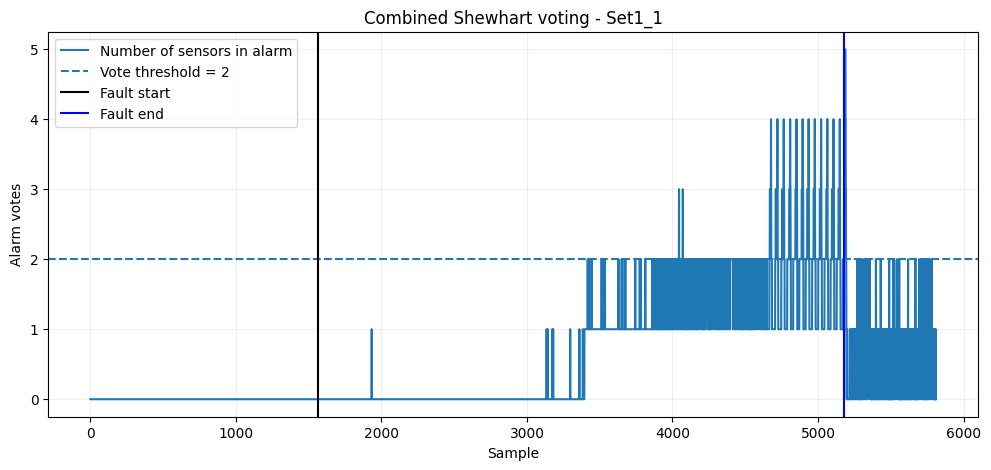

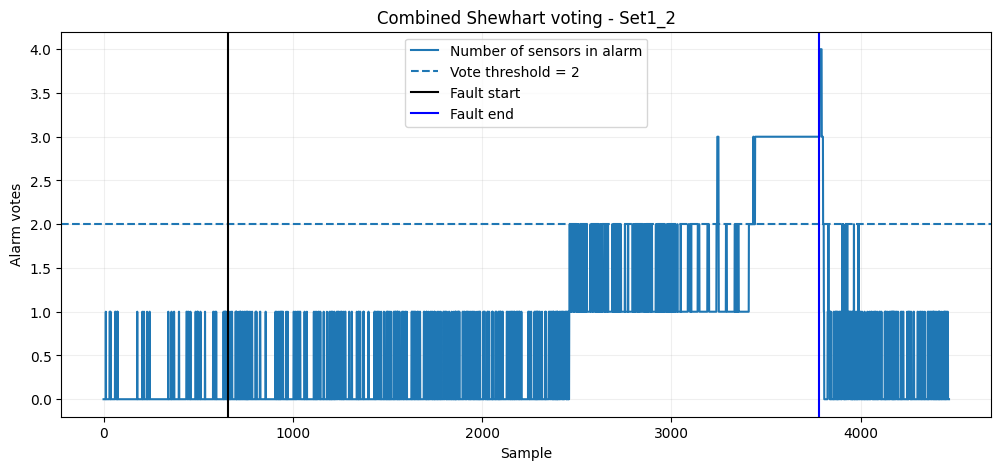

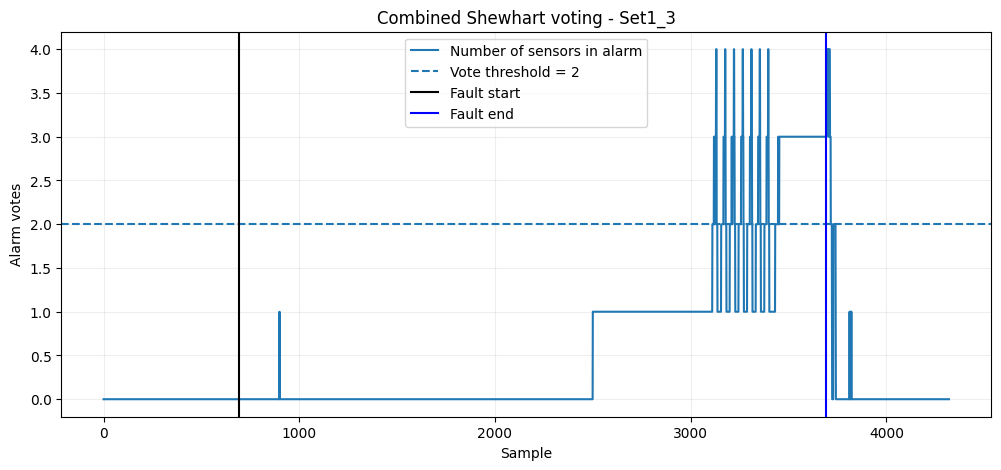

In [24]:
shewhart_results = {}

for name, dataset in datasets.items():
    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    alarm_df, votes, combined_alarm, max_z_score = shewhart_multisensor_alarm(
        dataset,
        shewhart_models,
        shewhart_sensors,
        vote_threshold=vote_threshold,
    )

    shewhart_results[name] = {
        "alarm_df": alarm_df,
        "votes": votes,
        "combined_alarm": combined_alarm,
        "max_z_score": max_z_score,
    }

    plt.figure(figsize=(12, 5))
    plt.plot(votes.values, label="Number of sensors in alarm")
    plt.axhline(vote_threshold, linestyle="--", label=f"Vote threshold = {vote_threshold}")
    plt.axvline(fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"Combined Shewhart voting - {name}")
    plt.xlabel("Sample")
    plt.ylabel("Alarm votes")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

## Shewhart score

Denne blok plotte max_z_score og det er den største afvigelse fra normalniveauet blandt de valgte sensorer. 

Hvis kurven går over 3, betyder det, at mindst en sensor er uden for sin ±3σ-grænse. Men den samlede alarm kræver stadig mindst 2 sensorer i alarm. 

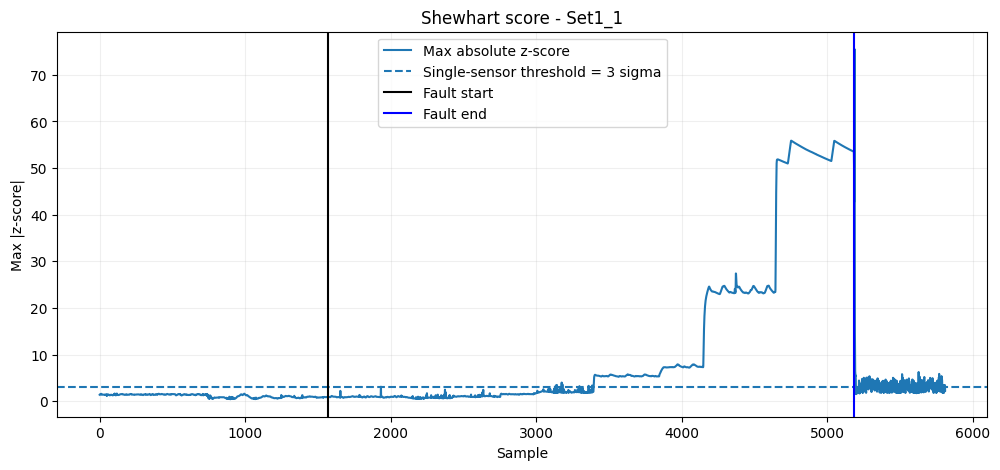

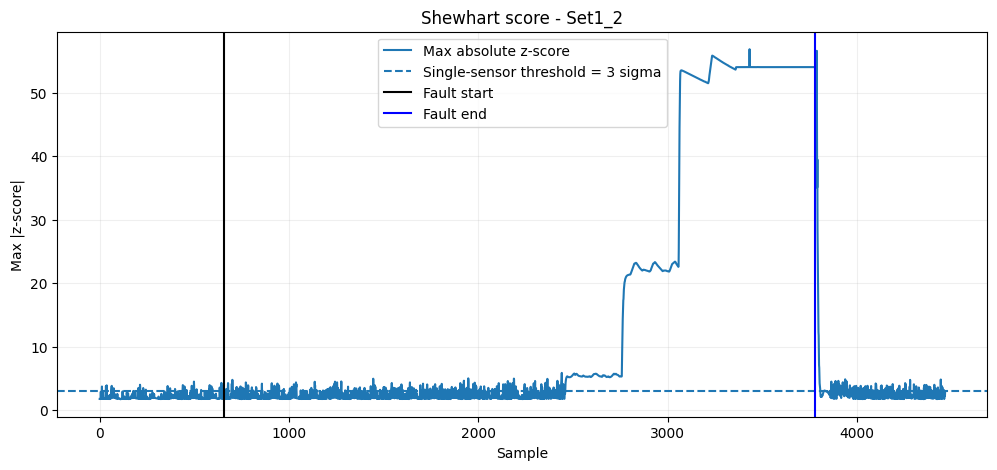

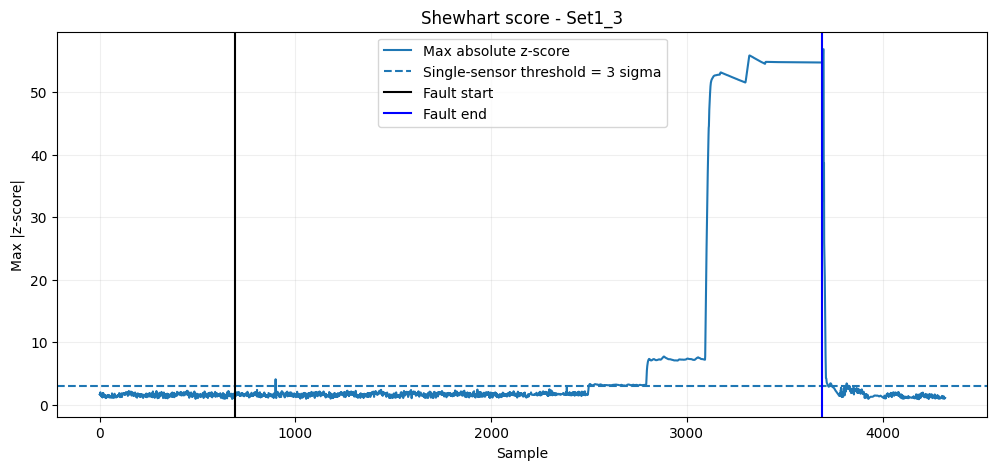

In [25]:
for name, result in shewhart_results.items():
    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    plt.figure(figsize=(12, 5))
    plt.plot(result["max_z_score"].values, label="Max absolute z-score")
    plt.axhline(k_sigma, linestyle="--", label=f"Single-sensor threshold = {k_sigma} sigma")
    plt.axvline(fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"Shewhart score - {name}")
    plt.xlabel("Sample")
    plt.ylabel("Max |z-score|")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

## Sensor-for-sensor Shewhart charts

Denne blok laver klassiske Shewhart control charts for hver sensor i Set1_1. Den viser: 
- Sensorens tidsserie 
- Center line (CL)
- øvre grænse (UCL)
- Nedre grænse (LCL)
- Punkter hvor sensoren bryder grænserne 
- Fault-start og fault-end 

Den er god til rapporten, fordi den forklarer, hvilke sensorer der faktisk driver alarmen. 

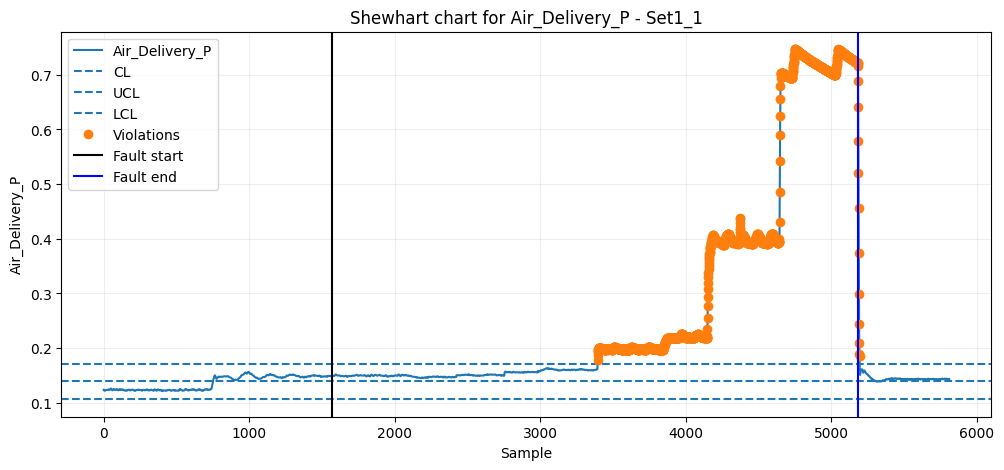

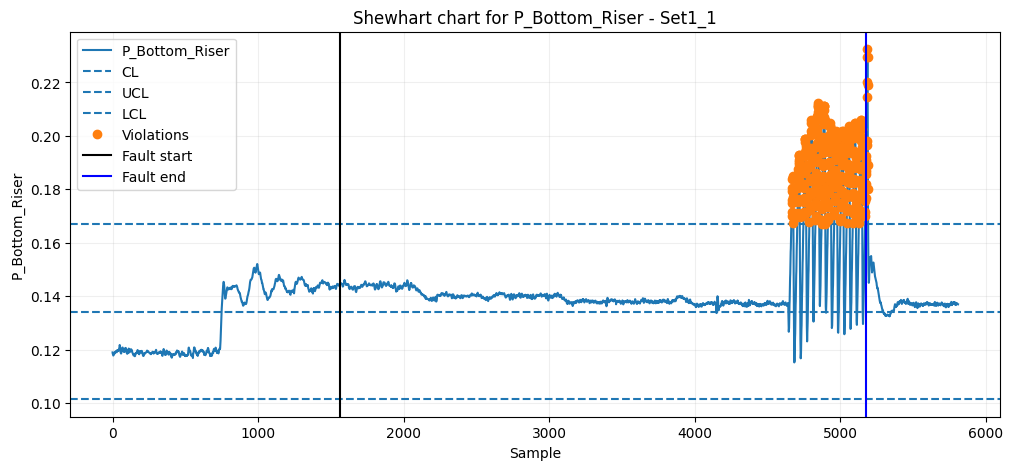

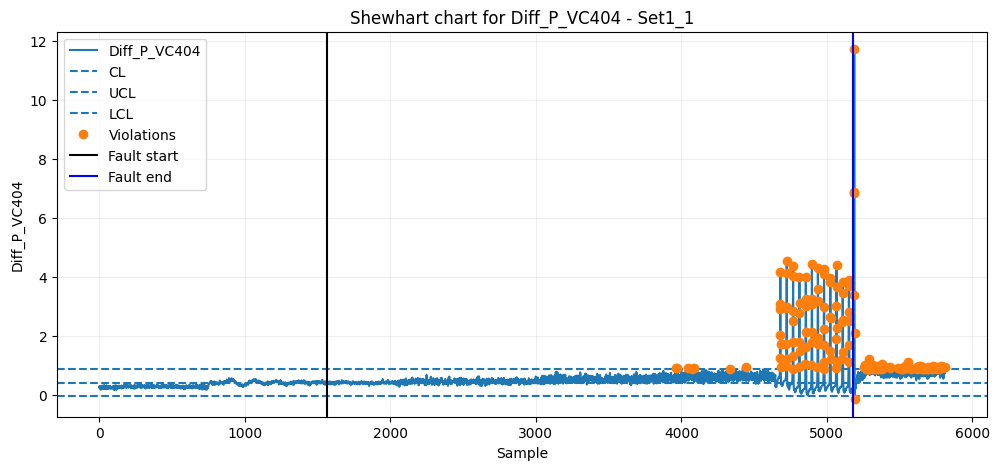

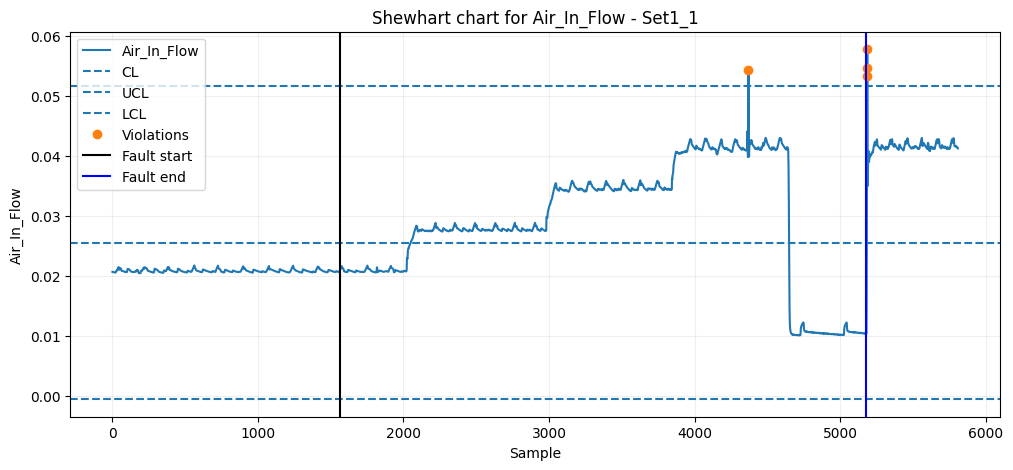

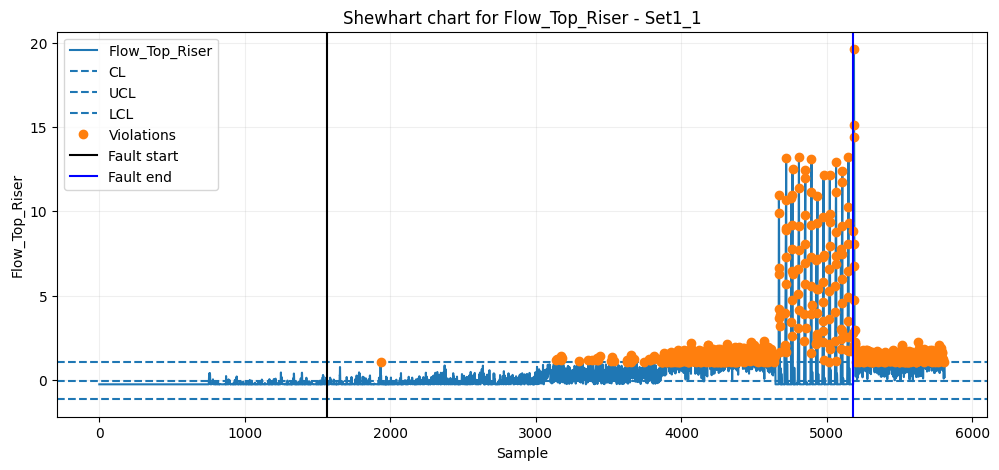

In [26]:
def plot_shewhart_sensor_chart(dataset_name, sensor):
    dataset = datasets[dataset_name]
    fault_start = fault_info[dataset_name]["start"]
    fault_end = fault_info[dataset_name]["end"]

    model = shewhart_models[sensor]
    test_series = dataset.sensors[sensor].interpolate().ffill().bfill()
    violations = shewhart_predict(test_series, model["LCL"], model["UCL"])

    plt.figure(figsize=(12, 5))
    plt.plot(test_series.values, label=sensor)
    plt.axhline(model["CL"], linestyle="--", label="CL")
    plt.axhline(model["UCL"], linestyle="--", label="UCL")
    plt.axhline(model["LCL"], linestyle="--", label="LCL")
    plt.plot(np.where(violations)[0], test_series[violations], "o", label="Violations")
    plt.axvline(fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"Shewhart chart for {sensor} - {dataset_name}")
    plt.xlabel("Sample")
    plt.ylabel(sensor)
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()


for sensor in shewhart_sensors:
    plot_shewhart_sensor_chart("Set1_1", sensor)

## Samlet evalueringstabel

Denne blok laver en summary tabel for Shewhart modellen pr. datasæt. Den evaluerer den samlede alarm Combined_alarm. Tabellen viser blandt andet detection delay, false alarm rate og fault detection rate. Det er nok den vigtigste tabel til sammenligning med PCA og FDA

In [27]:
summary_rows = []

for name, result in shewhart_results.items():
    metrics = evaluate_alarm(
        result["combined_alarm"],
        fault_info[name]["start"],
        fault_info[name]["end"],
    )

    summary_rows.append({
        "Dataset": name,
        "Model": f"Shewhart ({vote_threshold}-of-{len(shewhart_sensors)})",
        **metrics,
    })

shewhart_summary_df = pd.DataFrame(summary_rows)
display(shewhart_summary_df)

,Dataset,Model,first_alarm_after_fault,detection_delay,n_alarms_total,n_alarms_before_fault,n_alarms_during_fault,n_alarms_after_fault,false_alarm_rate_before_fault,fault_detection_rate
0,Set1_1,Shewhart (2-of-5),3417,1851,823,0,774,49,0.0,0.214049
1,Set1_2,Shewhart (2-of-5),2462,1805,623,0,584,39,0.0,0.187120
2,Set1_3,Shewhart (2-of-5),3111,2420,488,0,446,42,0.0,0.148617


## Sensor-evalueringstabel

Denne blok evaluerer hver sensor individuelt og formålet er at se, hvilke sensorer der er mest nyttige. 

Den sorterer efter: 
- Dataset
- Detection delay
- Antal false alarms før fault 

Så de bedste sensorer kommer typisk øverst. 

In [28]:
sensor_rows = []

for dataset_name, dataset in datasets.items():
    fault_start = fault_info[dataset_name]["start"]
    fault_end = fault_info[dataset_name]["end"]

    for sensor in shewhart_sensors:
        model = shewhart_models[sensor]

        alarms = shewhart_predict(
            dataset.sensors[sensor],
            model["LCL"],
            model["UCL"],
        )

        metrics = evaluate_alarm(alarms, fault_start, fault_end)

        sensor_rows.append({
            "Dataset": dataset_name,
            "Sensor": sensor,
            **metrics,
        })

sensor_eval_df = pd.DataFrame(sensor_rows)
display(sensor_eval_df.sort_values(
    ["Dataset", "detection_delay", "n_alarms_before_fault"],
    na_position="last",
))

,Dataset,Sensor,first_alarm_after_fault,detection_delay,n_alarms_total,n_alarms_before_fault,n_alarms_during_fault,n_alarms_after_fault,false_alarm_rate_before_fault,fault_detection_rate
4,Set1_1,Flow_Top_Riser,1933.0,367.0,896,0,590,306,0.000000,0.163164
0,Set1_1,Air_Delivery_P,3395.0,1829.0,1800,0,1787,13,0.000000,0.494192
2,Set1_1,Diff_P_VC404,3960.0,2394.0,169,0,84,85,0.000000,0.023230
3,Set1_1,Air_In_Flow,4371.0,2805.0,4,0,1,3,0.000000,0.000277
1,Set1_1,P_Bottom_Riser,4666.0,3100.0,278,0,268,10,0.000000,0.074115
9,Set1_2,Flow_Top_Riser,658.0,1.0,1127,55,886,186,0.083714,0.283883
5,Set1_2,Air_Delivery_P,2460.0,1803.0,1362,0,1318,44,0.000000,0.422301
6,Set1_2,P_Bottom_Riser,3238.0,2581.0,405,0,381,24,0.000000,0.122076
7,Set1_2,Diff_P_VC404,3783.0,3126.0,41,0,0,41,0.000000,0.000000
8,Set1_2,Air_In_Flow,NaN,NaN,0,0,0,0,0.000000,0.000000
